In [1]:
## usual impport functions : general use
import numpy as np
from numpy import cosh, zeros_like, mgrid, zeros
import matplotlib.pyplot as plt
import pandas as pd

# from interpolation.complete_poly import (CompletePolynomial,
#                                          n_complete, complete_polynomial,
#                                          complete_polynomial_der,
#                                          _complete_poly_impl,
#                                          _complete_poly_impl_vec,
#                                          _complete_poly_der_impl,
#                                          _complete_poly_der_impl_vec)
from numba import jit, vectorize

## scipy functions for optimization (not all used)
from scipy.optimize import root
from scipy.sparse import spdiags, kron
from scipy.sparse.linalg import spilu, LinearOperator
from scipy.optimize import leastsq
from scipy.optimize import minimize
from scipy.special import j1
from scipy.interpolate import interp1d ## 1d interpolation, 2d and radial basis are avaiable for higher dimension interpolation


### quantecon functions
# import quantecon as qe
# import quantecon_wasm as qe_w
# from quantecon import compute_fixed_point
# from quantecon.markov import DiscreteDP

# Parameter initialization

In [ ]:
beta*gamma

NameError: name 'beta' is not defined

In [10]:
alpha = 0.36
beta = 1/1.05
gamma =  1.4

h0 = 1
k0 = 10


# Equations and Dynamics

In [4]:
def lucas_uzawa(T,alpha,beta,gamma,h0,k0):
  k = [k0]
  h = [h0]
  c = [(1-alpha*beta)*((1-beta)**(1-alpha))*(h[0]**(1-alpha))*(k[0]**alpha)]
  u = beta

  for i in range(T):

    h.append(gamma*beta*h[i])
    k.append((alpha*beta*(1-beta)**(1-alpha))*(h[i]**(1-alpha))*(k[i]**alpha))
    c.append((1-alpha*beta)*((1-beta)**(1-alpha))*(h[i]**(1-alpha))*(k[i]**alpha))



  return k,h,c


In [11]:
k,h,c = lucas_uzawa(40,alpha,beta,gamma,h0,k0)

In [15]:
k[:11]

[10,
 0.11191617354952918,
 0.02669654573177301,
 0.019157474744879634,
 0.020436993253570134,
 0.025146997542497673,
 0.032574054628809704,
 0.04298247873422287,
 0.057095688925170356,
 0.0760249912502459,
 0.10131745502992054]

In [16]:
h[:11]

[1,
 1.3333333333333333,
 1.7777777777777777,
 2.3703703703703702,
 3.1604938271604937,
 4.213991769547325,
 5.6186556927297655,
 7.491540923639687,
 9.988721231519582,
 13.318294975359443,
 17.757726633812588]

In [17]:
c[:11]

[0.2145059993032643,
 0.2145059993032643,
 0.05116837931923161,
 0.03671849326101931,
 0.039170903736009434,
 0.048198411956453885,
 0.06243360470521862,
 0.08238308424059385,
 0.10943340377324322,
 0.14571456656297133,
 0.19419178880734775]

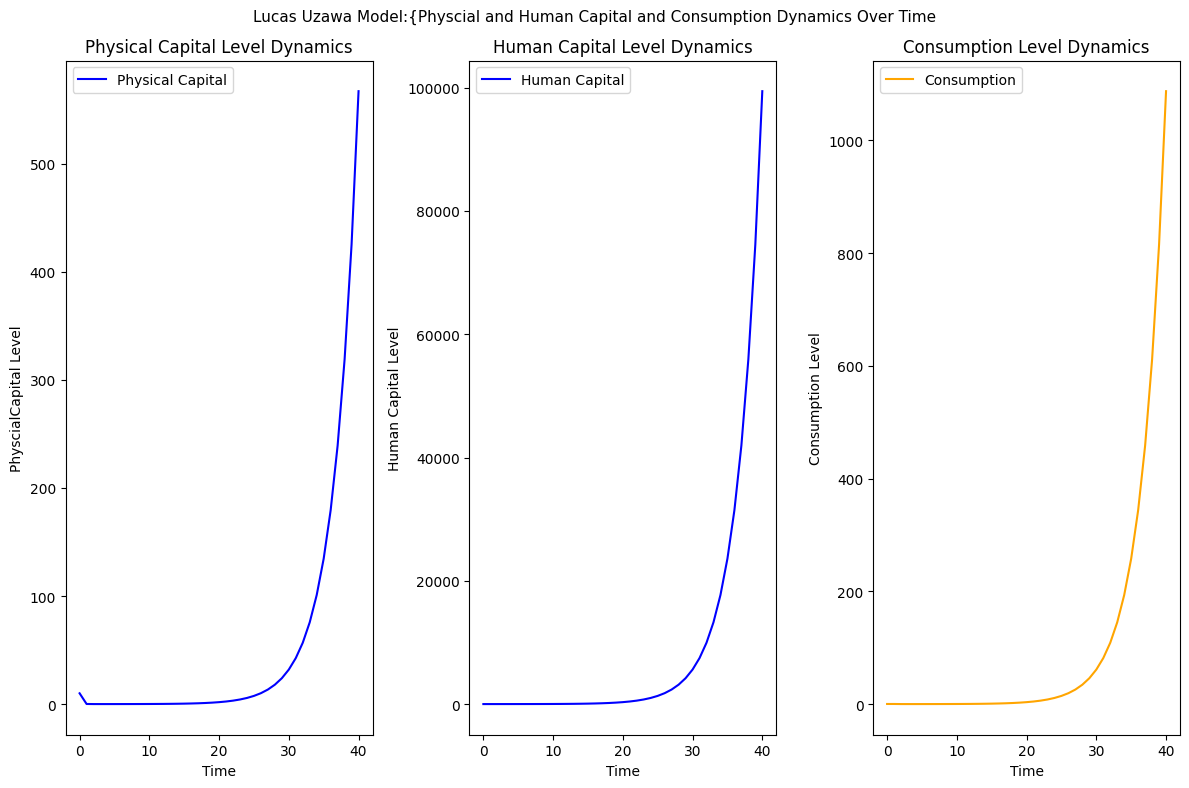

In [12]:
#### plot the capital and output dynamics
fig, axes = plt.subplots(1, 3, figsize=(12, 8)) # Create a figure with 1x2 subplots

# Plot Capital levels dynamics on the first subplot
axes[0].plot(k, label="Physical Capital", color = "blue")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("PhyscialCapital Level")
axes[0].set_title("Physical Capital Level Dynamics")
axes[0].legend()
#axes[0].axhline(y=k_star, color='r', linestyle='--', label='k = k_ss_old') # Add horizontal line for steady state capital
#axes[0].axhline(y=k_star, color='g', linestyle='--', label='k = k_ss_new') # Add horizontal line for steady state capital


axes[1].plot(h, label="Human Capital", color = "blue")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Human Capital Level")
axes[1].set_title("Human Capital Level Dynamics")
axes[1].legend()
#axes[0].axhline(y=k_star, color='r', linestyle='--', label='k = k_ss_old') # Add horizontal line for steady state capital
#axes[0].axhline(y=k_star, color='g', linestyle='--', label='k = k_ss_new') # Add horizontal line for steady state capital

# Plot Consumption levels dynamics on the second subplot
axes[2].plot(c, label="Consumption", color='orange')
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Consumption Level")
axes[2].set_title("Consumption Level Dynamics")
axes[2].legend()
#axes[1].axhline(y=c_star, color='r', linestyle='--', label='y = c_ss_old') # Add horizontal line for steady state consumption
#axes[1].axhline(y=c_star, color='g', linestyle='--', label='y = c_ss_new') # Add horizontal line for steady state consumption


# Add a main title for the figure
fig.suptitle("Lucas Uzawa Model:{Physcial and Human Capital and Consumption Dynamics Over Time", fontsize=11)

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()